In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pylot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StanadardScaler
from sklearn.tree import DecisionTree
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import Train_test_split


In [2]:
df = pd.read_csv("Tesla.csv - Tesla.csv.csv")

In [3]:
df

,Date,Open,High,Low,Close,Volume,Adj Close
0,6/29/2010,19.000000,25.000000,17.540001,23.889999,18766300,23.889999
1,6/30/2010,25.790001,30.420000,23.299999,23.830000,17187100,23.830000
2,7/1/2010,25.000000,25.920000,20.270000,21.959999,8218800,21.959999
3,7/2/2010,23.000000,23.100000,18.709999,19.200001,5139800,19.200001
4,7/6/2010,20.000000,20.000000,15.830000,16.110001,6866900,16.110001
...,...,...,...,...,...,...,...
1687,3/13/2017,244.820007,246.850006,242.779999,246.169998,3010700,246.169998
1688,3/14/2017,246.110001,258.119995,246.020004,258.000000,7575500,258.000000
1689,3/15/2017,257.000000,261.000000,254.270004,255.729996,4816600,255.729996
1690,3/16/2017,262.399994,265.750000,259.059998,262.049988,7100400,262.049988


In [5]:
df.head()

,Date,Open,High,Low,Close,Volume,Adj Close
0,6/29/2010,19.000000,25.00,17.540001,23.889999,18766300,23.889999
1,6/30/2010,25.790001,30.42,23.299999,23.830000,17187100,23.830000
2,7/1/2010,25.000000,25.92,20.270000,21.959999,8218800,21.959999
3,7/2/2010,23.000000,23.10,18.709999,19.200001,5139800,19.200001
4,7/6/2010,20.000000,20.00,15.830000,16.110001,6866900,16.110001


In [7]:
df.index

RangeIndex(start=0, stop=1692, step=1)

In [9]:
df.shape

(1692, 7)

In [11]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Adj Close'], dtype='object')

In [12]:
df.isna()

,Date,Open,High,Low,Close,Volume,Adj Close
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
1687,False,False,False,False,False,False,False
1688,False,False,False,False,False,False,False
1689,False,False,False,False,False,False,False
1690,False,False,False,False,False,False,False


In [14]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
1687    False
1688    False
1689    False
1690    False
1691    False
Length: 1692, dtype: bool

In [15]:
df.drop_duplicates()

,Date,Open,High,Low,Close,Volume,Adj Close
0,6/29/2010,19.000000,25.000000,17.540001,23.889999,18766300,23.889999
1,6/30/2010,25.790001,30.420000,23.299999,23.830000,17187100,23.830000
2,7/1/2010,25.000000,25.920000,20.270000,21.959999,8218800,21.959999
3,7/2/2010,23.000000,23.100000,18.709999,19.200001,5139800,19.200001
4,7/6/2010,20.000000,20.000000,15.830000,16.110001,6866900,16.110001
...,...,...,...,...,...,...,...
1687,3/13/2017,244.820007,246.850006,242.779999,246.169998,3010700,246.169998
1688,3/14/2017,246.110001,258.119995,246.020004,258.000000,7575500,258.000000
1689,3/15/2017,257.000000,261.000000,254.270004,255.729996,4816600,255.729996
1690,3/16/2017,262.399994,265.750000,259.059998,262.049988,7100400,262.049988


In [16]:
df[["Open", "Low"]].mean()

Open    132.441572
Low     129.996223
dtype: float64

In [17]:
df["Volume"].unique()

array([18766300, 17187100,  8218800, ...,  4816600,  7100400,  6475900],
      shape=(1676,))

In [19]:
df["Close"].value_counts()

Close
27.420000     4
31.490000     3
26.500000     3
20.540001     3
27.120001     3
             ..
46.970001     1
45.450001     1
45.590000     1
43.299999     1
261.500000    1
Name: count, Length: 1528, dtype: int64

In [20]:
df.dropna(subset=["Open", "High", "Low", "Close", "Volume", "Adj Close"])

,Date,Open,High,Low,Close,Volume,Adj Close
0,6/29/2010,19.000000,25.000000,17.540001,23.889999,18766300,23.889999
1,6/30/2010,25.790001,30.420000,23.299999,23.830000,17187100,23.830000
2,7/1/2010,25.000000,25.920000,20.270000,21.959999,8218800,21.959999
3,7/2/2010,23.000000,23.100000,18.709999,19.200001,5139800,19.200001
4,7/6/2010,20.000000,20.000000,15.830000,16.110001,6866900,16.110001
...,...,...,...,...,...,...,...
1687,3/13/2017,244.820007,246.850006,242.779999,246.169998,3010700,246.169998
1688,3/14/2017,246.110001,258.119995,246.020004,258.000000,7575500,258.000000
1689,3/15/2017,257.000000,261.000000,254.270004,255.729996,4816600,255.729996
1690,3/16/2017,262.399994,265.750000,259.059998,262.049988,7100400,262.049988


In [22]:
df.fillna(method = "ffill", inplace = True)

C:\Users\HP USER\AppData\Local\Temp\ipykernel_15844\1412035681.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method = "ffill", inplace = True)


In [28]:
df.groupby("High")["Low"].mean().reset_index()

,High,Low
0,16.629999,14.980000
1,17.520000,15.570000
2,17.900000,16.969999
3,18.070000,17.000000
4,18.450001,17.660000
...,...,...
1465,285.489990,277.000000
1466,286.649994,272.540009
1467,287.390015,278.609985
1468,288.000000,280.100006


In [27]:
df.groupby("High")["Low"].sum().reset_index()

,High,Low
0,16.629999,14.980000
1,17.520000,15.570000
2,17.900000,33.939998
3,18.070000,17.000000
4,18.450001,17.660000
...,...,...
1465,285.489990,277.000000
1466,286.649994,272.540009
1467,287.390015,278.609985
1468,288.000000,280.100006


In [29]:
sort_values = df.sort_values(by=["Open", "Low"])

In [30]:
sort_values

,Date,Open,High,Low,Close,Volume,Adj Close
6,7/8/2010,16.139999,17.520000,15.570000,17.459999,7711400,17.459999
5,7/7/2010,16.400000,16.629999,14.980000,15.800000,6921700,15.800000
9,7/13/2010,17.389999,18.639999,16.900000,18.139999,2680100,18.139999
7,7/9/2010,17.580000,17.900000,16.549999,17.400000,4050600,17.400000
31,8/12/2010,17.799999,17.900000,17.389999,17.600000,691000,17.600000
...,...,...,...,...,...,...,...
1059,9/12/2014,280.500000,282.390015,277.000000,279.200012,3324600,279.200012
1054,9/5/2014,282.549988,282.899994,272.510010,277.390015,11169900,277.390015
1056,9/9/2014,282.989990,285.489990,277.000000,278.480011,4558800,278.480011
1053,9/4/2014,284.010010,291.420013,280.399994,286.040009,8341700,286.040009


In [32]:
High_by_rate = df.groupby("Date")["High"].max().sort_values(ascending = False)

In [33]:
High_by_rate

Date
9/4/2014     291.420013
9/3/2014     288.000000
2/14/2017    287.390015
7/20/2015    286.649994
9/9/2014     285.489990
                ...    
7/12/2010     18.070000
8/12/2010     17.900000
7/9/2010      17.900000
7/8/2010      17.520000
7/7/2010      16.629999
Name: High, Length: 1692, dtype: float64

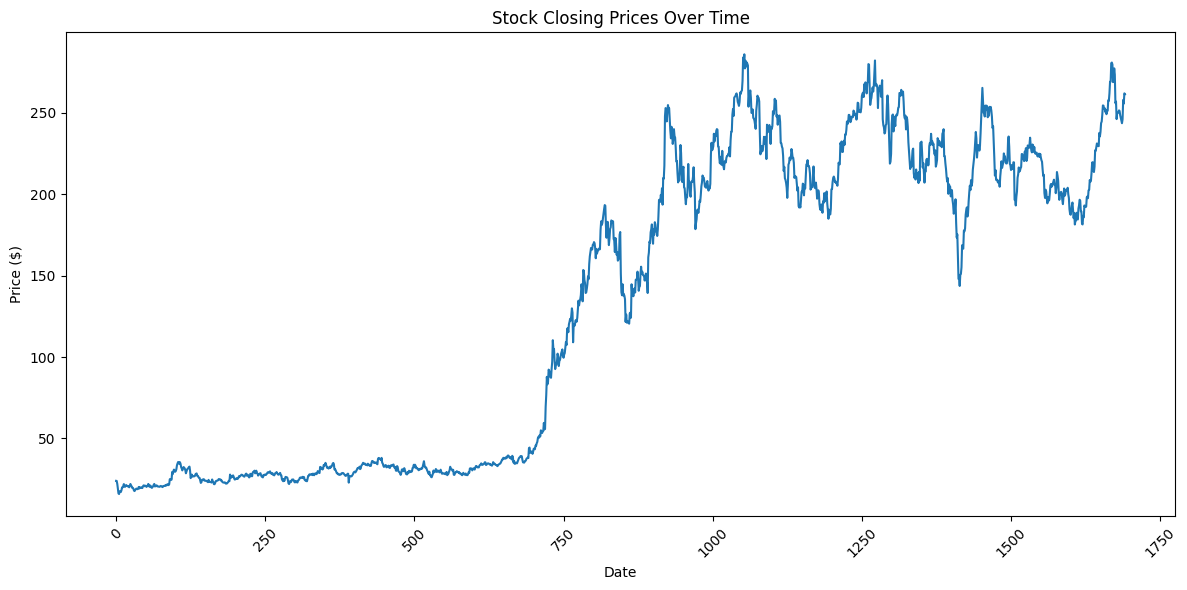

In [34]:
# I want to know the stock closing by price
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x=df.index, y='Close')
plt.title('Stock Closing Prices Over Time')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

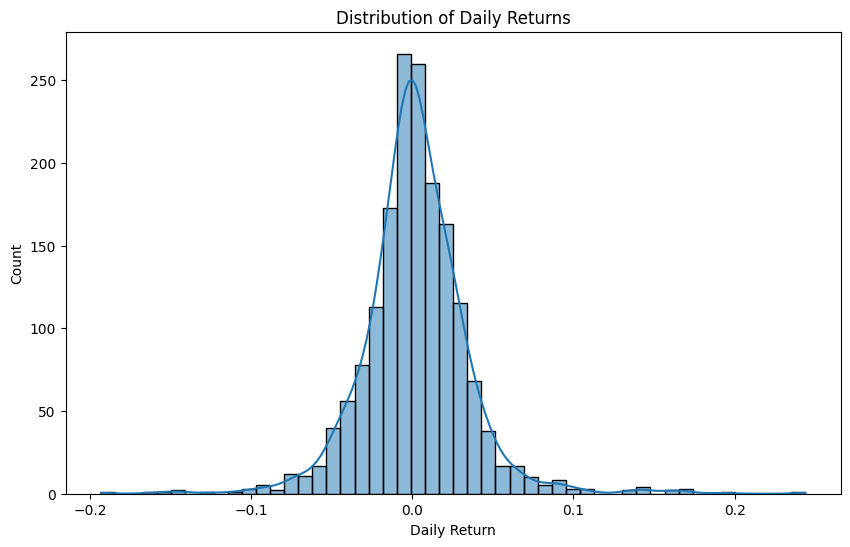

In [35]:
# Visualize daily returns volatility
df['Returns'] = df['Close'].pct_change()
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Returns', bins=50, kde=True)
plt.title('Distribution of Daily Returns')
plt.xlabel('Daily Return')
plt.show()

# The kernel density below estimate (KDE) overlays a smooth curve to assess normality/volatility.

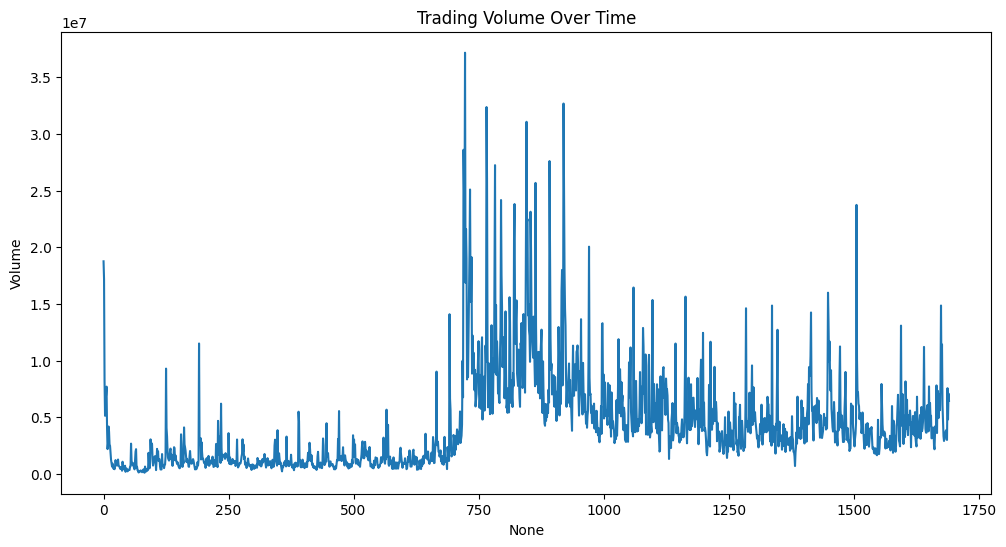

In [36]:
# This compares volumetric analysis of the trade in market overtime 
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x=df.index, y='Volume')
plt.title('Trading Volume Over Time')
plt.ylabel('Volume')
plt.show()

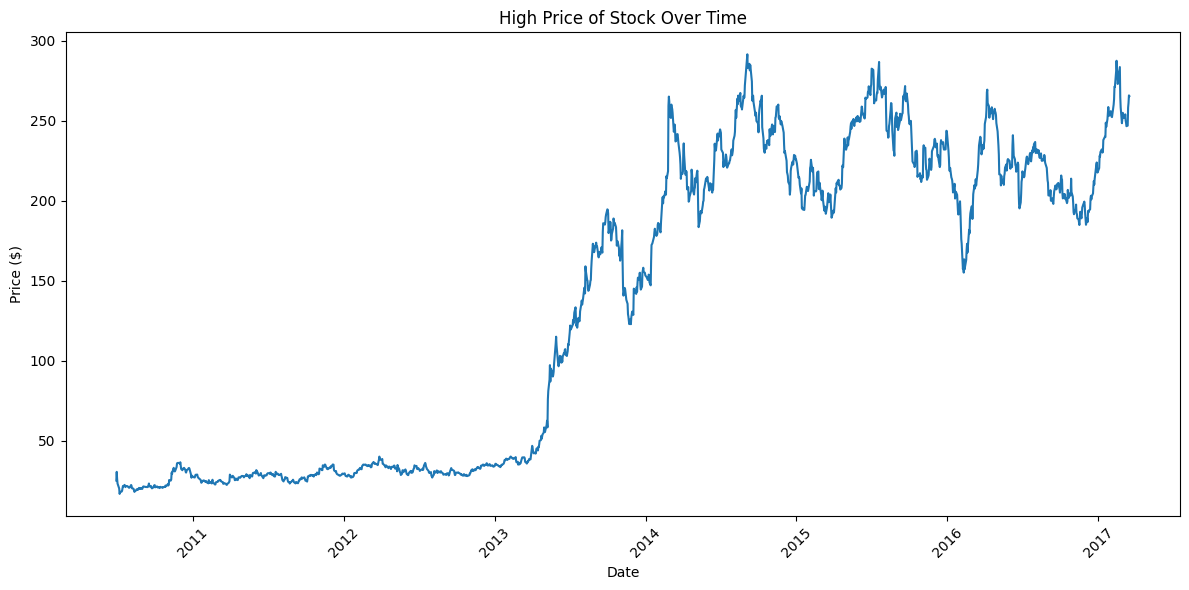

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Ensure Date column exists and is datetime (from your earlier work)
if 'Date' not in df.columns:
    print("Available columns:", df.columns.tolist())
else:
    df['Date'] = pd.to_datetime(df['Date'])
    
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Date', y='High')  # Use Date column directly
plt.title("High Price of Stock Over Time")
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [40]:
low_by_date = df.groupby("Date")["Low"].min().sort_values(ascending=False)

In [41]:
low_by_date 

Date
2014-09-04    280.399994
2014-09-03    280.100006
2014-09-11    278.630005
2017-02-14    278.609985
2014-09-08    277.519989
                 ...    
2010-07-13     16.900000
2010-07-09     16.549999
2010-07-06     15.830000
2010-07-08     15.570000
2010-07-07     14.980000
Name: Low, Length: 1692, dtype: float64

C:\Users\HP USER\AppData\Local\Temp\ipykernel_15844\598578492.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_lows.index, x=top_lows.values, palette='viridis')


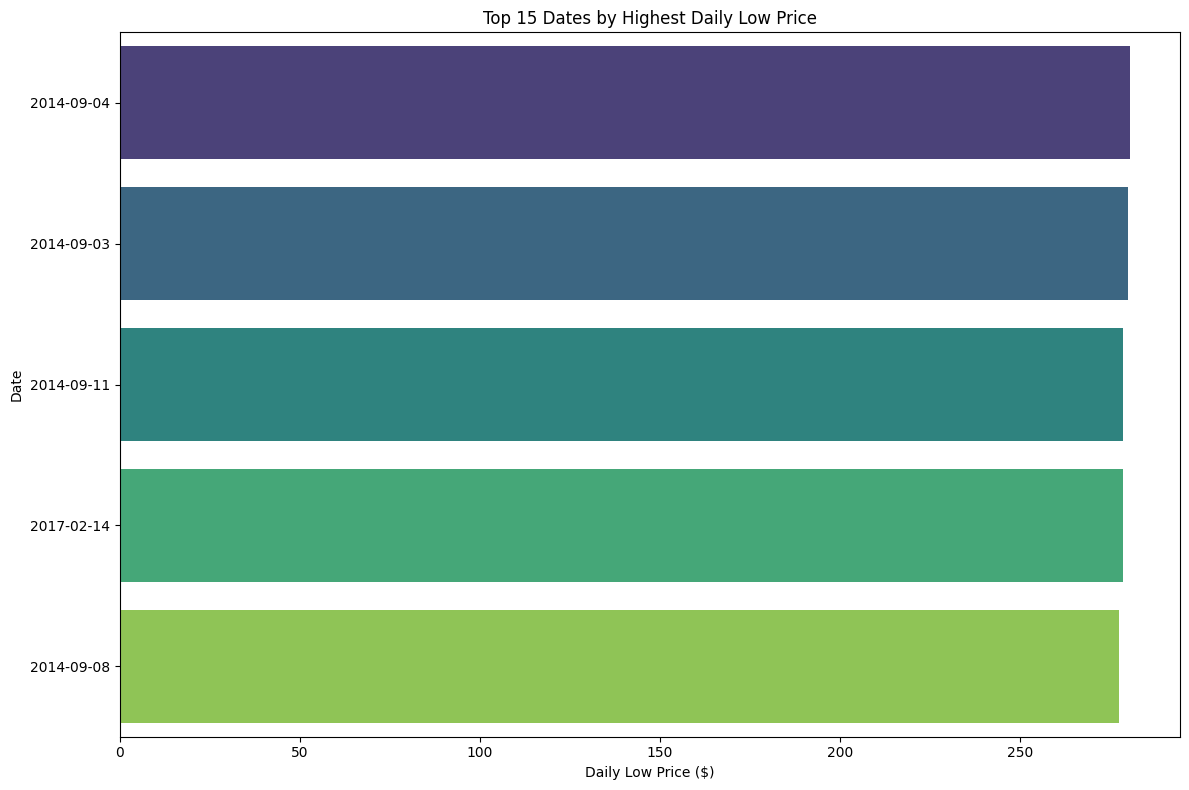

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
top_lows = low_by_date.head(5)
sns.barplot(y=top_lows.index, x=top_lows.values, palette='viridis')
plt.title('Top 15 Dates by Highest Daily Low Price')
plt.xlabel('Daily Low Price ($)')
plt.ylabel('Date')
plt.tight_layout()
plt.show()


In [44]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Adj Close',
       'Returns'],
      dtype='object')

In [46]:
df["Date"] = pd.to_datetime(df["Date"])
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Quarter"] = df["Date"].dt.quarter
df["Hours"] = df["Date"].dt.hour
df["Day"] = df["Date"].dt.day
df["Week"] = df["Date"].dt.isocalendar().week
df["Month_Name"] = df["Date"].dt.month_name()
df["Day_Name"] = df["Date"].dt.day_name()
df["Week_Abbr"] = df["Date"].dt.day_name().str[:3]

In [47]:
df.head(5)

,Date,Open,High,Low,Close,Volume,Adj Close,Returns,Year,Month,Quarter,Hours,Day,Week,Month_Name,Day_Name,Week_Abbr
0,2010-06-29,19.000000,25.00,17.540001,23.889999,18766300,23.889999,NaN,2010,6,2,0,29,26,June,Tuesday,Tue
1,2010-06-30,25.790001,30.42,23.299999,23.830000,17187100,23.830000,-0.002511,2010,6,2,0,30,26,June,Wednesday,Wed
2,2010-07-01,25.000000,25.92,20.270000,21.959999,8218800,21.959999,-0.078473,2010,7,3,0,1,26,July,Thursday,Thu
3,2010-07-02,23.000000,23.10,18.709999,19.200001,5139800,19.200001,-0.125683,2010,7,3,0,2,26,July,Friday,Fri
4,2010-07-06,20.000000,20.00,15.830000,16.110001,6866900,16.110001,-0.160937,2010,7,3,0,6,27,July,Tuesday,Tue


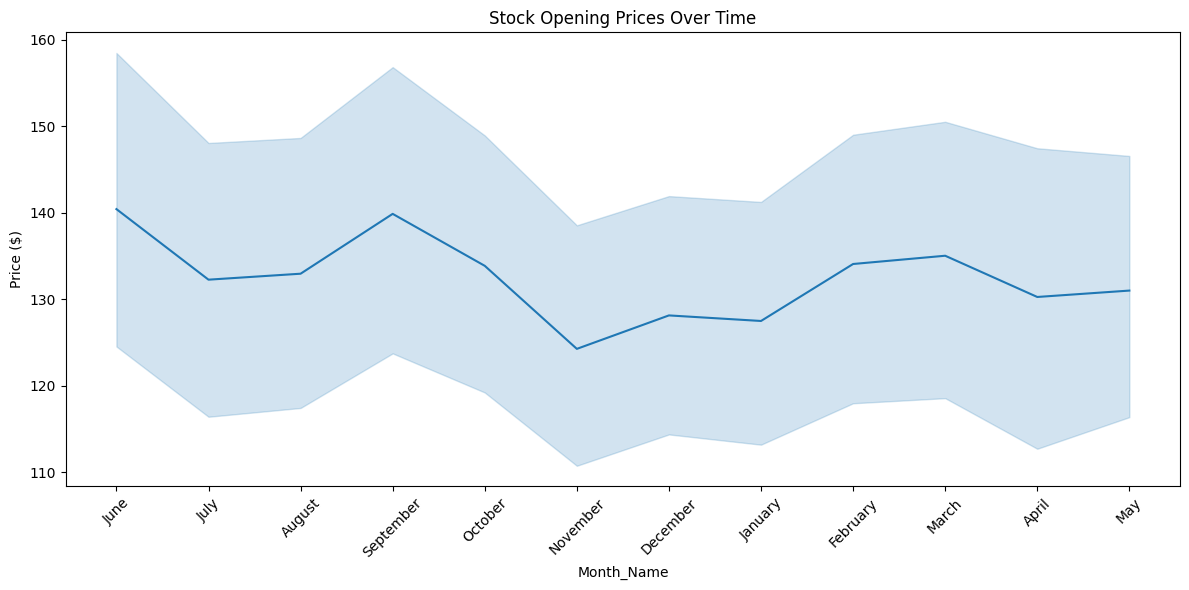

In [50]:
# I want to know the stock closing by price
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x="Month_Name", y='Open')
plt.title('Stock Opening Prices Over Time')
plt.xlabel('Month_Name')
plt.ylabel('Price ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [57]:
Re = df["Returns"]

In [58]:
Re

0            NaN
1      -0.002511
2      -0.078473
3      -0.125683
4      -0.160937
          ...   
1687    0.010177
1688    0.048056
1689   -0.008798
1690    0.024714
1691   -0.002099
Name: Returns, Length: 1692, dtype: float64

In [60]:
Re.dropna()

1      -0.002511
2      -0.078473
3      -0.125683
4      -0.160937
5      -0.019243
          ...   
1687    0.010177
1688    0.048056
1689   -0.008798
1690    0.024714
1691   -0.002099
Name: Returns, Length: 1691, dtype: float64

<Axes: >

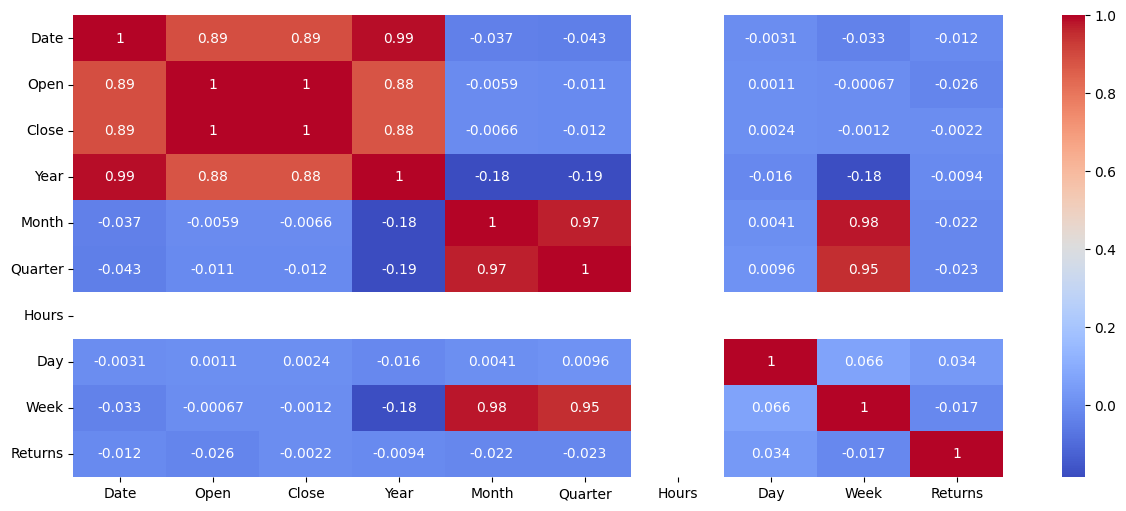

In [61]:
plt.figure(figsize = (15, 6))
numerical_col = ["Date",	"Open",	"Close",	"Year",	"Month",	"Quarter",	"Hours",	"Day",	"Week",	"Returns"]
corrolation_matrix = df[numerical_col].corr()
sns.heatmap(corrolation_matrix, cmap = "coolwarm", annot = True)

In [63]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Adj Close',
       'Returns', 'Year', 'Month', 'Quarter', 'Hours', 'Day', 'Week',
       'Month_Name', 'Day_Name', 'Week_Abbr'],
      dtype='object')

In [67]:
from sklearn.preprocessing import LabelEncoder

# columns to encode
cols = ['Month_Name', 'Day_Name', 'Week_Abbr']

# Label encoding object
le = LabelEncoder()

# label encoding for each column with assignment
for col in cols:
    df[col] = le.fit_transform(df[col])


<Axes: >

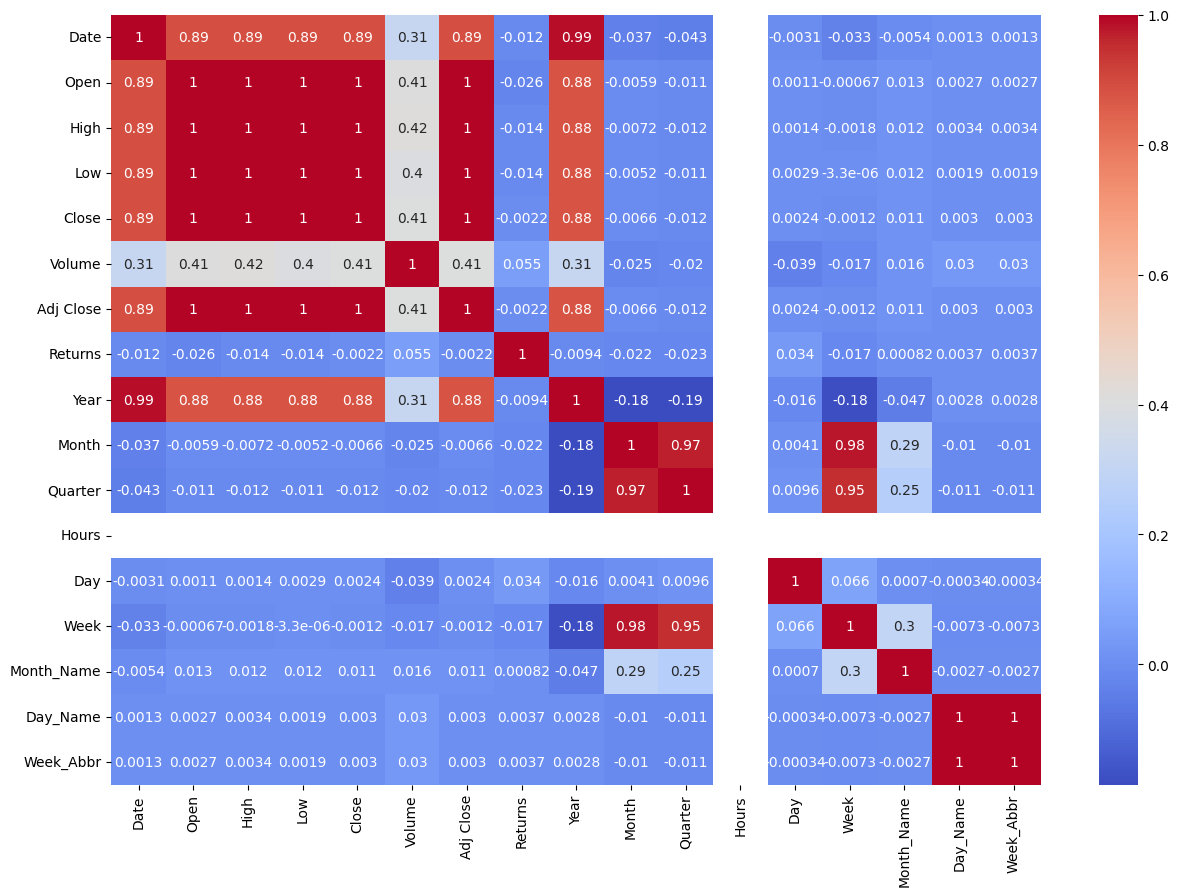

In [68]:
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

In [79]:
df.columns 

Index(['Open', 'High', 'Low', 'Close', 'Volume', 'Adj Close', 'Returns',
       'Year', 'Month', 'Quarter', 'Day'],
      dtype='object')

In [86]:
df.dropna()

,Open,High,Low,Close,Volume,Adj Close,Returns,Year,Month,Quarter,Day
1,25.790001,30.420000,23.299999,23.830000,17187100,23.830000,-0.002511,2010,6,2,30
2,25.000000,25.920000,20.270000,21.959999,8218800,21.959999,-0.078473,2010,7,3,1
3,23.000000,23.100000,18.709999,19.200001,5139800,19.200001,-0.125683,2010,7,3,2
4,20.000000,20.000000,15.830000,16.110001,6866900,16.110001,-0.160937,2010,7,3,6
5,16.400000,16.629999,14.980000,15.800000,6921700,15.800000,-0.019243,2010,7,3,7
...,...,...,...,...,...,...,...,...,...,...,...
1687,244.820007,246.850006,242.779999,246.169998,3010700,246.169998,0.010177,2017,3,1,13
1688,246.110001,258.119995,246.020004,258.000000,7575500,258.000000,0.048056,2017,3,1,14
1689,257.000000,261.000000,254.270004,255.729996,4816600,255.729996,-0.008798,2017,3,1,15
1690,262.399994,265.750000,259.059998,262.049988,7100400,262.049988,0.024714,2017,3,1,16


In [93]:
df["Returns"].dropna()

1      -0.002511
2      -0.078473
3      -0.125683
4      -0.160937
5      -0.019243
          ...   
1687    0.010177
1688    0.048056
1689   -0.008798
1690    0.024714
1691   -0.002099
Name: Returns, Length: 1691, dtype: float64

In [94]:
# Strip spaces from column names
df.columns = df.columns.str.strip()

In [95]:
from sklearn.model_selection import train_test_split

In [104]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

# Clean the FULL DataFrame first (keeps rows aligned)
df_clean = df.dropna()

# Split AFTER cleaning (guarantees matching shapes)
X = df_clean.drop('Volume', axis=1)  # Replace with your target (e.g., 'Close')
y = df_clean['Close']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [105]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

model = LinearRegression()
model.fit(X_train, y_train)
pred = model.predict(X_test)
mae = mean_absolute_error(pred, y_test)
mse = mean_squared_error(pred, y_test)
score = r2_score(pred, y_test)

print(f"Mean Absolute Error(MAE): {mae} ")
print(f"Mean Squared Error(MSE): {mse}")
print(f"R2 Squared Score(RSS): {score}")

Mean Absolute Error(MAE): 6.791027916999188e-14 
Mean Squared Error(MSE): 5.193990513281019e-27
R2 Squared Score(RSS): 1.0


In [107]:
from sklearn.tree import DecisionTreeRegressor
tree = DecisionTreeRegressor()
tree.fit(X_train, y_train)
pred = tree.predict(X_test)
mae = mean_absolute_error(pred, y_test)
mse = mean_squared_error(pred, y_test)
score = r2_score(pred, y_test)

print(f"Mean Absolute Error(MAE): {mae} ")
print(f"Mean Squared Error(MSE): {mse}")
print(f"R2 Squared Score(RSS): {score}")

Mean Absolute Error(MAE): 0.16091439823008905 
Mean Squared Error(MSE): 0.12152286404136071
R2 Squared Score(RSS): 0.9999868696320795


In [109]:
from sklearn.ensemble import RandomForestRegressor
ensemble = RandomForestRegressor()
ensemble.fit(X_train, y_train)
pred = ensemble.predict(X_test)
mae = mean_absolute_error(pred, y_test)
mse = mean_squared_error(pred, y_test)
score = r2_score(pred, y_test)

print(f"Mean Absolute Error(MAE): {mae} ")
print(f"Mean Squared Error(MSE): {mse}")
print(f"R2 Squared Score(RSS): {score}")

Mean Absolute Error(MAE): 0.15042031097346392 
Mean Squared Error(MSE): 0.2449356560286756
R2 Squared Score(RSS): 0.9999735663804074


In [110]:
from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import LinearRegression

model = LinearRegression()

params = {
    # Example of valid parameters for LinearRegression
    'fit_intercept': [True, False],
    'positive': [True, False]
}

grid = GridSearchCV(model, param_grid=params, cv=5, n_jobs=-1)
grid.fit(X_train, y_train)

#best parameters
print(grid.best_params_)

{'fit_intercept': True, 'positive': True}


In [111]:

from sklearn.linear_model import LinearRegression
import pandas as pd

model = LinearRegression()
model.fit(X_train, y_train)

feat_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_
})

# Absolute value as importance and sort
feat_df['Importance'] = feat_df['Coefficient'].abs()
feat_df = feat_df.sort_values(by='Importance', ascending=False).drop(columns='Importance')

print(feat_df)

# Save to CSV
feat_df.to_csv('linear_model_feature_importance.csv', index=False)


     Feature   Coefficient
3      Close  5.000000e-01
4  Adj Close  5.000000e-01
5    Returns -4.747875e-14
8    Quarter  6.361350e-15
1       High  1.942890e-15
2        Low -1.859624e-15
7      Month -1.727053e-15
6       Year -1.636278e-15
0       Open  3.963302e-16
9        Day -2.381450e-16


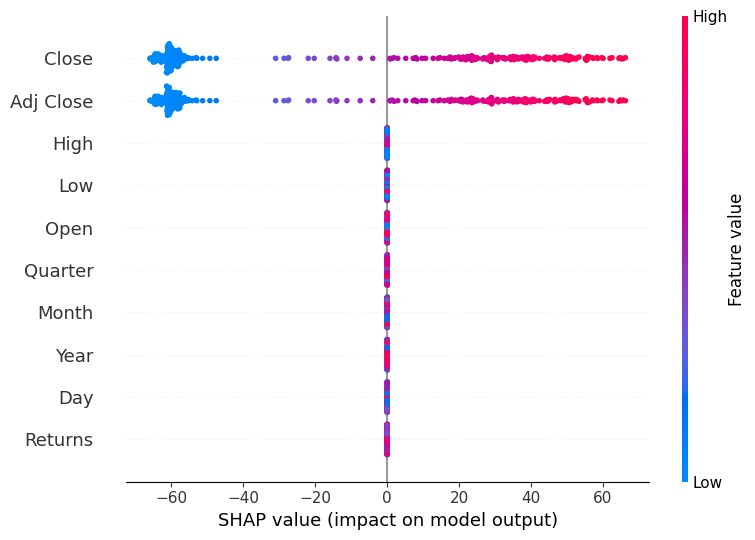

In [112]:
import shap
explainer = shap.LinearExplainer(model, X_train)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

In [114]:
import pickle

# Assume 'best_model' is the trained model you want to save
filename = "model.pkl"

# Save the model to disk
with open(filename, 'wb') as file:
    pickle.dump(model, file)
